In [1]:
from header import *
from calibrate import calibrate

print("\n")

#load in the data
data,calibration=load("Data\Zeeman Data\data_z5\\")

GROUP_SIZE=10
N_GROUPS=N_POINTS//GROUP_SIZE

#group the data
grouped_data=group(data,N_GROUPS,GROUP_SIZE)

print("Creating first graph")

def scale_time(t):
    return 2*10**(-6)*t+-93*10**(-3)

def scale_voltage(v):
    return 400*10**(-6)*v


<>:7: SyntaxWarning: invalid escape sequence '\Z'
<>:7: SyntaxWarning: invalid escape sequence '\Z'
C:\Users\Student\AppData\Local\Temp\ipykernel_8700\3826009824.py:7: SyntaxWarning: invalid escape sequence '\Z'
  data,calibration=load("Data\Zeeman Data\data_z5\\")




Loading Files
Grouping Data
Creating first graph


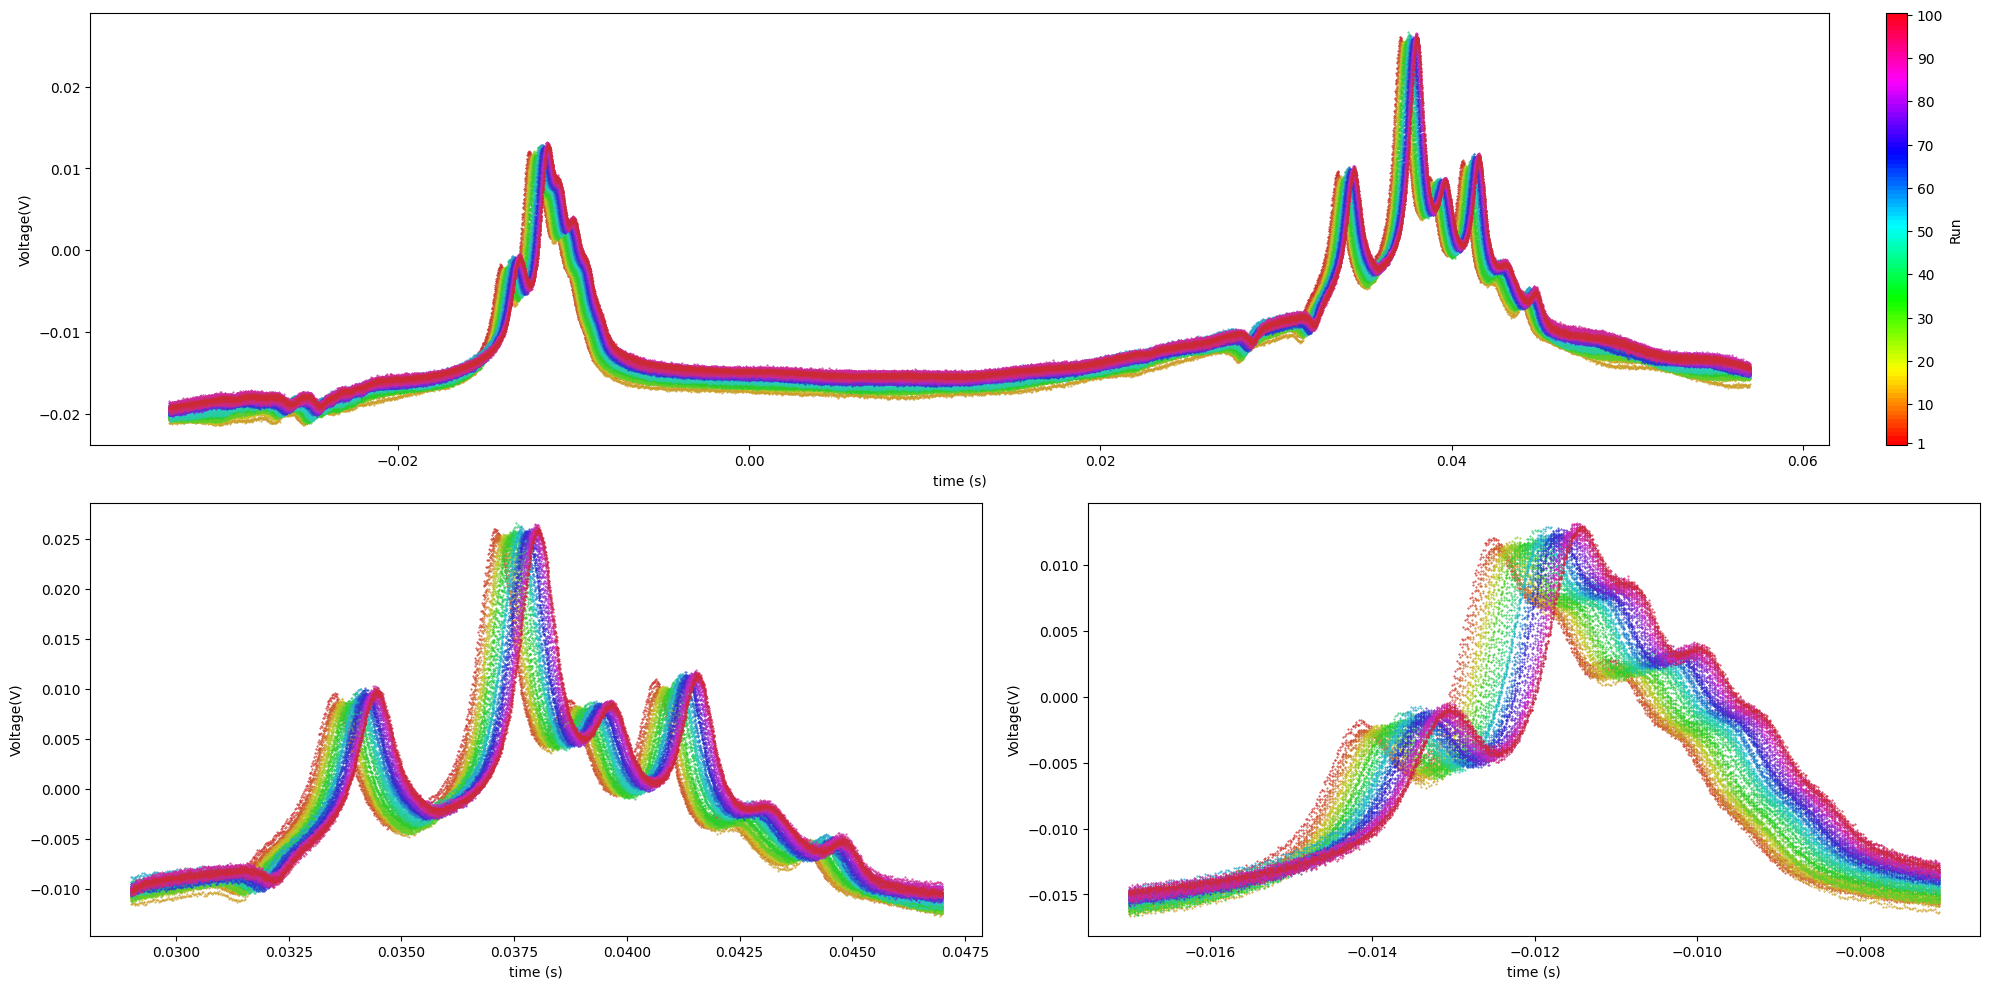

In [2]:

#layout
fig, axs = plt.subplots(2,2,figsize=(20,10))
gs = axs[1, 1].get_gridspec()
for ax in axs[0, :]:
    ax.remove()
axbig = fig.add_subplot(gs[0, :])

#add the colour bar
fig.colorbar(cm.ScalarMappable(cmap='hsv'),ax=axbig,label="Run",ticks=[1,10,20,30,40,50,60,70,80,90,100],boundaries=np.linspace(0.5,100.5,101),values=np.linspace(0,0.99,100),fraction=0.05,pad=0.03)

#the full spectrum
for i in range(100):
    spec=scale_voltage(unp.nominal_values(grouped_data[i,3000:7500]))
    col=hsv_to_rgb((i/100,0.8,0.8))
    axbig.scatter(scale_time(np.arange(3000,7500)*GROUP_SIZE),spec,s=0.2,color=col)

for i in range(100):
    spec=scale_voltage(unp.nominal_values(grouped_data[i,6100:7000]))
    col=hsv_to_rgb((i/100,0.8,0.8))
    axs[1,0].scatter(scale_time(np.arange(6100,7000)*GROUP_SIZE),spec,s=0.2,color=col)

for i in range(100):
    spec=scale_voltage(unp.nominal_values(grouped_data[i,3800:4300]))
    col=hsv_to_rgb((i/100,0.8,0.8))
    axs[1,1].scatter(scale_time(np.arange(3800,4300)*GROUP_SIZE),spec,s=0.2,color=col)

axbig.set_xlabel("time (s)")
axs[1,0].set_xlabel("time (s)")
axs[1,1].set_xlabel("time (s)")
axbig.set_ylabel("Voltage(V)")
axs[1,0].set_ylabel("Voltage(V)")
axs[1,1].set_ylabel("Voltage(V)")

fig.tight_layout()

fig.savefig("all_doppler_free.png",dpi=300)

In [3]:
p=calibrate(calibration)

Grouping Data
18000 75000
570 570
Warning high reduced chi_squared value: 52.8+/-0.6
Warning high reduced chi_squared value: 65.8+/-0.7


c:\Users\Student\Documents\GitHub\doppler-free-laser-spectroscopy\calibrate.py:65: OptimizeWarning: Covariance of the parameters could not be estimated
  popt,pcov=curve_fit(
c:\Users\Student\AppData\Local\Programs\Python\Python312\Lib\site-packages\uncertainties\core.py:133: RuntimeWarning: invalid value encountered in divide
  covariance_mat / norm_vector / norm_vector[:, numpy.newaxis],


LinAlgError: Eigenvalues did not converge

c:\Users\Student\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\Student\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


<Figure size 2000x1000 with 0 Axes>

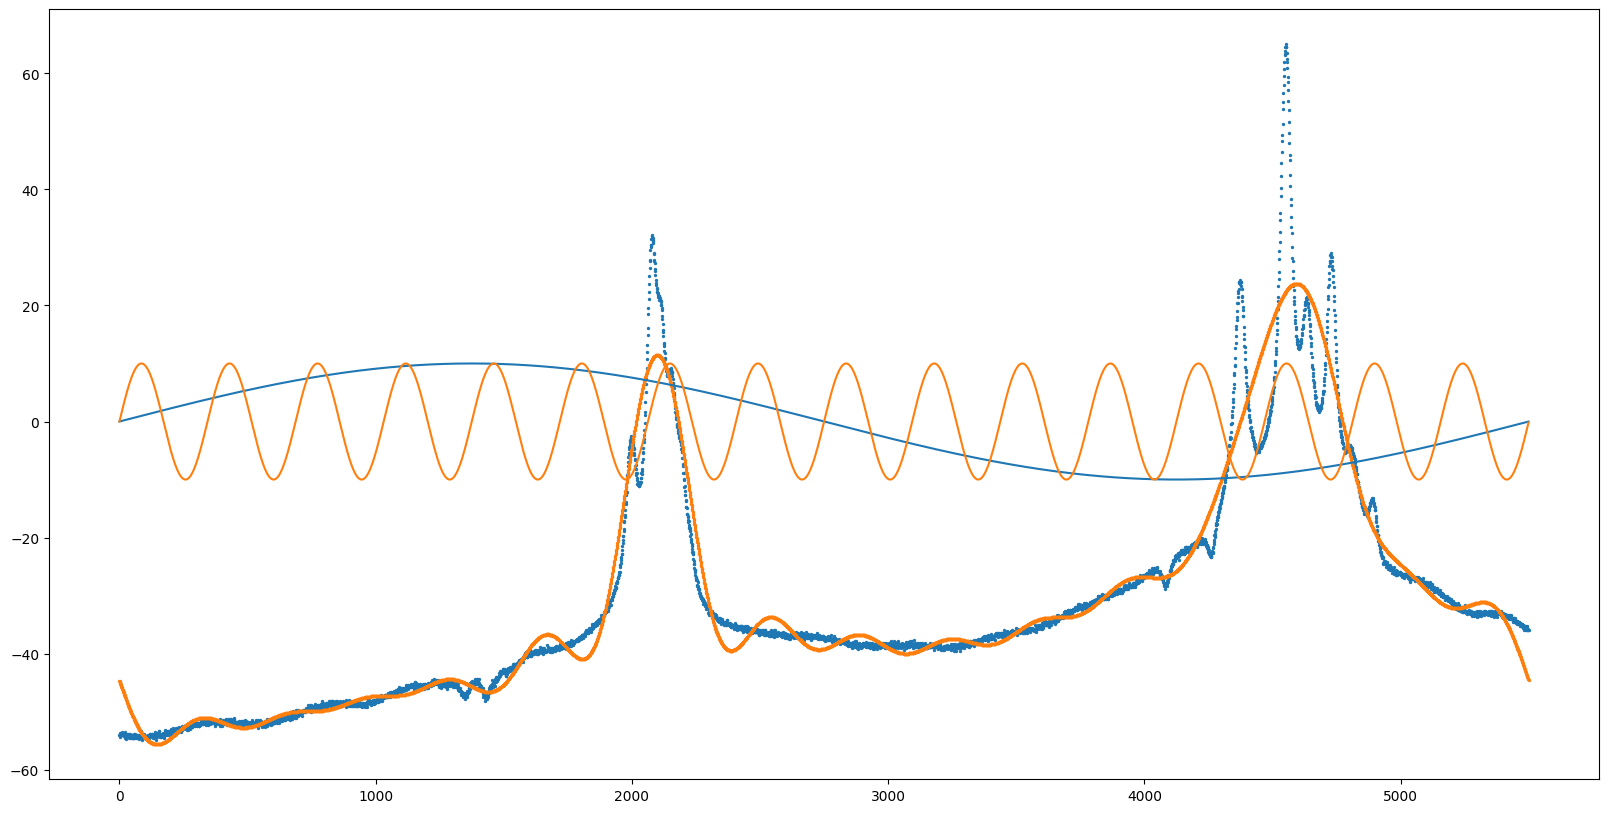

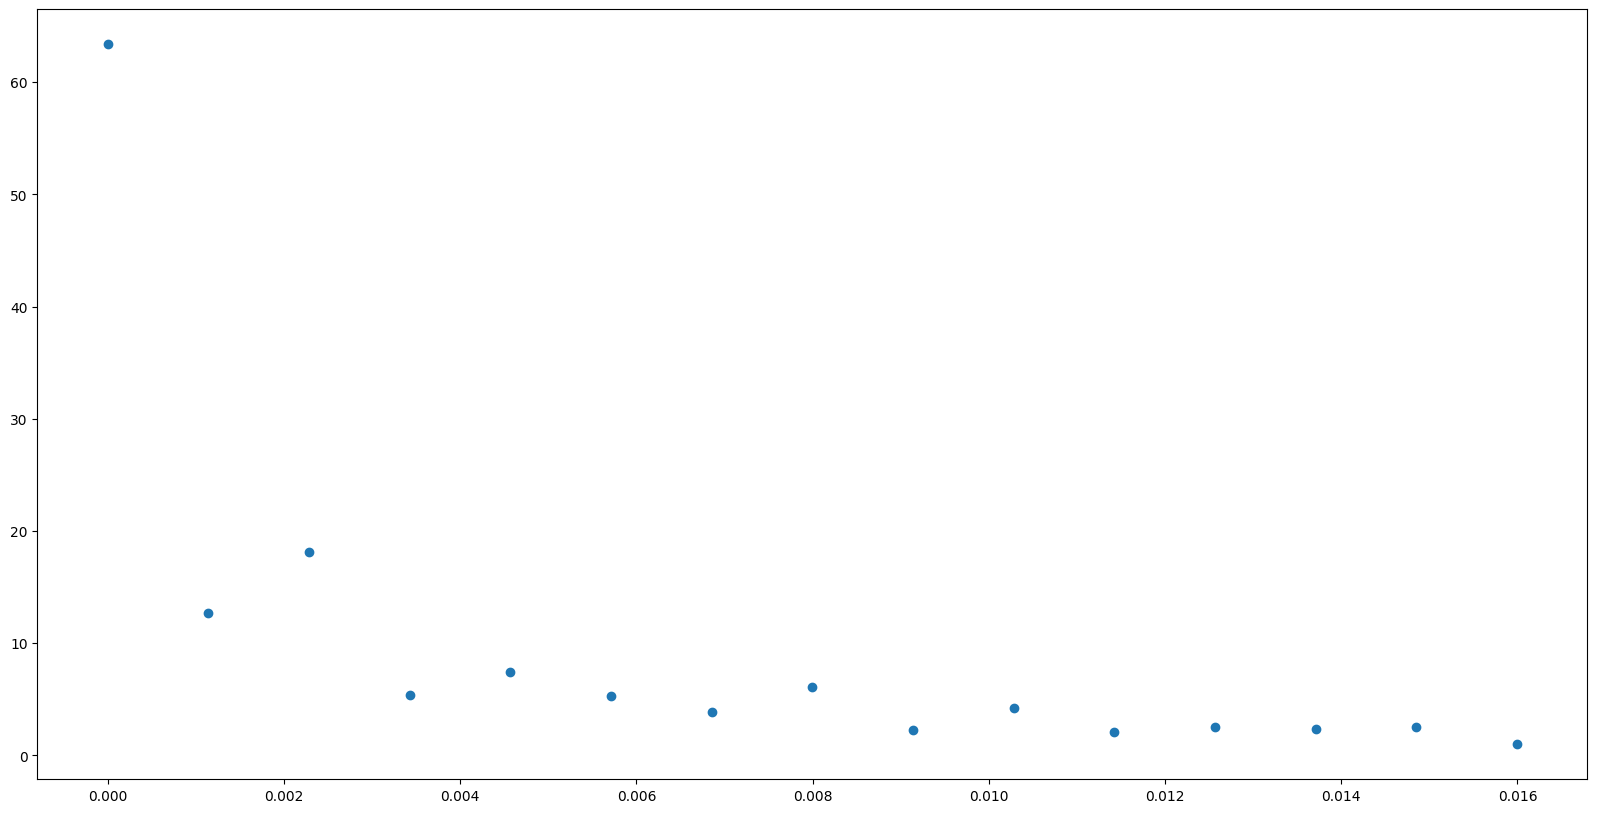

In [4]:
xs=unp.nominal_values(grouped_data[i,2000:7500])
N=len(xs)
ts=np.arange(0,N)
plt.show()

plt.figure(figsize=(20,10))
from scipy.fft import *
fs=rfft(xs)

s=0
e=15


def y(t):
    y=np.full((N),fs[0]/N)
    for i in range(1,len(fs))[s:s+e]:
        A=2*np.absolute(fs[i])/N
        omega=2 * np.pi *(i)/N
        phi=np.angle(fs[i])
        y+=A * np.cos( omega*t+phi)
    return y

rxs=y(ts)

plt.figure(figsize=(20,10))
plt.scatter(ts,xs,s=2)
plt.scatter(ts,rxs,s=2)
plt.plot(ts,10*np.sin(ts*2 * np.pi *(s+1)/N))
plt.plot(ts,10*np.sin(ts*2*np.pi*(e+1)/N))
plt.show()
plt.figure(figsize=(20,10))
plt.scatter(2 * np.pi *(np.arange(N//2+1)[s:s+e])/N,2*np.absolute(fs[s:s+e])/N)


NameError: name 'sinusoidal' is not defined

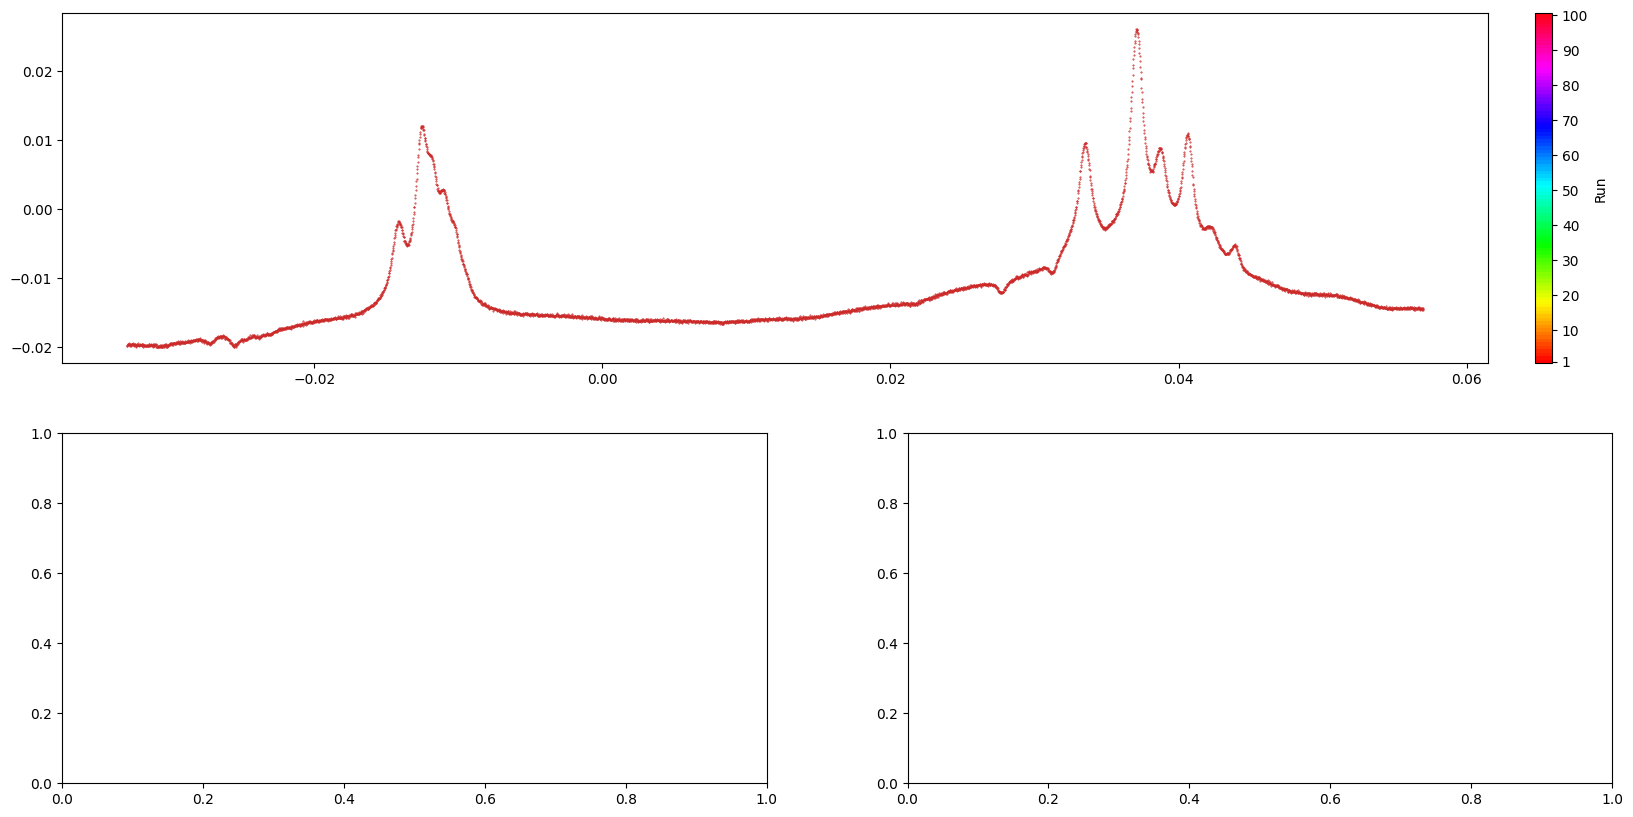

In [ ]:
#layout
fig, axs = plt.subplots(2,2,figsize=(20,10))
gs = axs[1, 1].get_gridspec()
for ax in axs[0, :]:
    ax.remove()
axbig = fig.add_subplot(gs[0, :])

#add the colour bar
fig.colorbar(cm.ScalarMappable(cmap='hsv'),ax=axbig,label="Run",ticks=[1,10,20,30,40,50,60,70,80,90,100],boundaries=np.linspace(0.5,100.5,101),values=np.linspace(0,0.99,100),fraction=0.05,pad=0.03)

#the full spectrum
for i in range(1):
    spec=scale_voltage(unp.nominal_values(grouped_data[i,3000:7500]))
    col=hsv_to_rgb((i/100,0.8,0.8))
    axbig.scatter(scale_time(np.arange(3000,7500)*GROUP_SIZE),spec,s=0.2,color=col)
    axbig.scatter(scale_time(np.arange(3000,7500)*GROUP_SIZE),scale_voltage(sinusoidal(np.arange(3000,7500)*GROUP_SIZE,*unp.nominal_values(paramiters[0]))),s=0.2,color=col)
for i in range(1):
    spec=scale_voltage(unp.nominal_values(grouped_data[i,6100:7000]))
    col=hsv_to_rgb((i/100,0.8,0.8))
    axs[1,0].scatter(scale_time(np.arange(6100,7000)*GROUP_SIZE),spec,s=0.2,color=col)

for i in range(1):
    spec=scale_voltage(unp.nominal_values(grouped_data[i,3800:4300]))
    col=hsv_to_rgb((i/100,0.8,0.8))
    axs[1,1].scatter(scale_time(np.arange(3800,4300)*GROUP_SIZE),spec,s=0.2,color=col)

axbig.set_xlabel("time (s)")
axs[1,0].set_xlabel("time (s)")
axs[1,1].set_xlabel("time (s)")
axbig.set_ylabel("Voltage(V)")
axs[1,0].set_ylabel("Voltage(V)")
axs[1,1].set_ylabel("Voltage(V)")

fig.tight_layout()

fig.savefig("all_doppler_free.png",dpi=300)

In [11]:
print(paramiters[0])

(-0.013399767756822781+/-0.46521584590669546, 0.9998167726971496+/-0.002653080724885285, 14.582378507167835+/-143.47114822148353, -32.825109183504175+/-0.3289608798658371)
